# CPE 342 Machine Learning — Assignment 3: Regression (Survival Analysis)
**Author:** 67070501042 WISIT SUWANNAO

## Course Module: Regression & Survival Analysis
**Instructor:** Dr. Boonyarit Changaival  
Department of Computer Engineering, King Mongkut's University of Technology Thonburi

---

# 1. Load data

In [1]:
!wget -O mtcars.csv https://www.dropbox.com/scl/fi/n0e5sbzbc1sf90n4kr72h/mtcars.csv?rlkey=66jca705l0jnrj94eigxiwtpn&dl=1

In [2]:
import pandas as pd

mtcars = pd.read_csv('mtcars.csv', index_col=0)
mtcars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


# 2. Assess correlations between variables

### As a correlation matrix

In [3]:
mtcars.corr()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
mpg,1.000000,-0.852162,-0.847551,-0.776168,0.681172,-0.867659,0.418684,0.664039,0.599832,0.480285,-0.550925
cyl,-0.852162,1.000000,0.902033,0.832447,-0.699938,0.782496,-0.591242,-0.810812,-0.522607,-0.492687,0.526988
disp,-0.847551,0.902033,1.000000,0.790949,-0.710214,0.887980,-0.433698,-0.710416,-0.591227,-0.555569,0.394977
hp,-0.776168,0.832447,0.790949,1.000000,-0.448759,0.658748,-0.708223,-0.723097,-0.243204,-0.125704,0.749812
drat,0.681172,-0.699938,-0.710214,-0.448759,1.000000,-0.712441,0.091205,0.440278,0.712711,0.699610,-0.090790
wt,-0.867659,0.782496,0.887980,0.658748,-0.712441,1.000000,-0.174716,-0.554916,-0.692495,-0.583287,0.427606
qsec,0.418684,-0.591242,-0.433698,-0.708223,0.091205,-0.174716,1.000000,0.744535,-0.229861,-0.212682,-0.656249
vs,0.664039,-0.810812,-0.710416,-0.723097,0.440278,-0.554916,0.744535,1.000000,0.168345,0.206023,-0.569607
am,0.599832,-0.522607,-0.591227,-0.243204,0.712711,-0.692495,-0.229861,0.168345,1.000000,0.794059,0.057534
gear,0.480285,-0.492687,-0.555569,-0.125704,0.699610,-0.583287,-0.212682,0.206023,0.794059,1.000000,0.274073


### As a heatmap

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(font_scale=1.2)

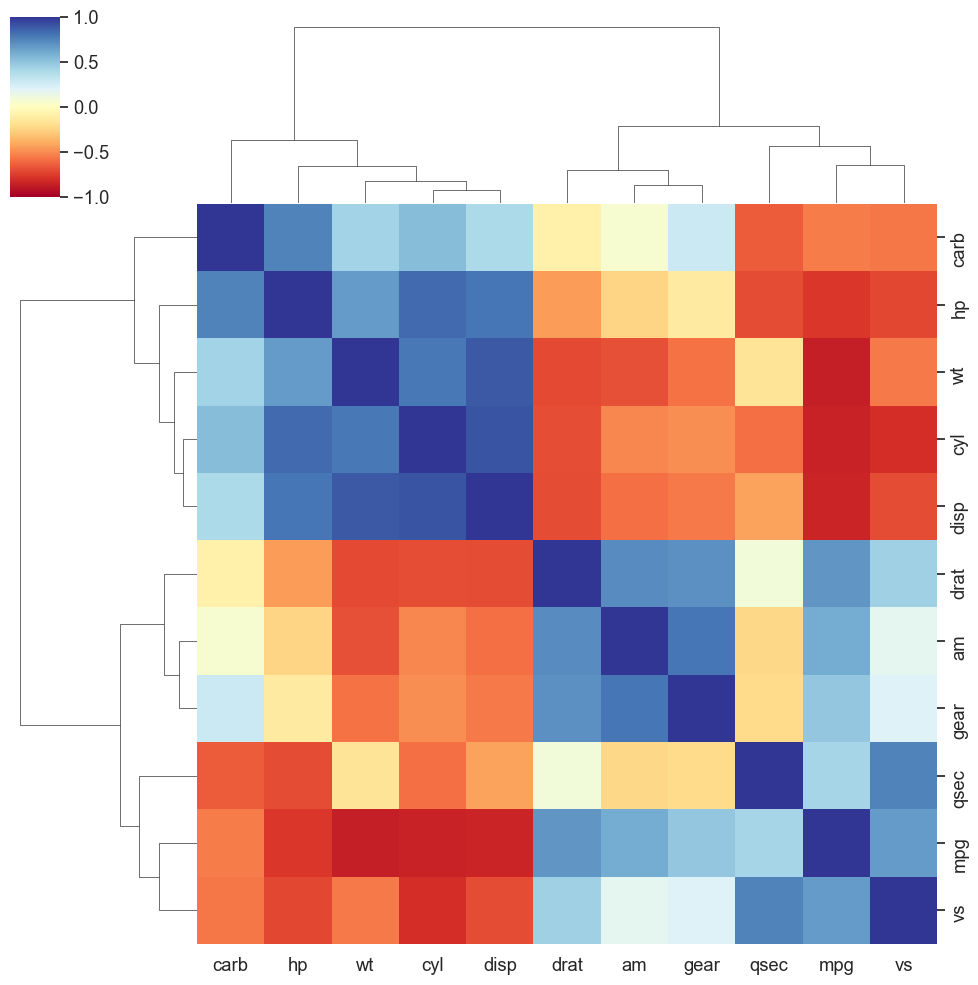

In [5]:
sns.clustermap(mtcars.corr(), cmap='RdYlBu', vmin=-1, vmax=1)
plt.show()

# 3. Visualize a linear relationship as a scatterplot

### Negative relationship

Correlation = -0.87


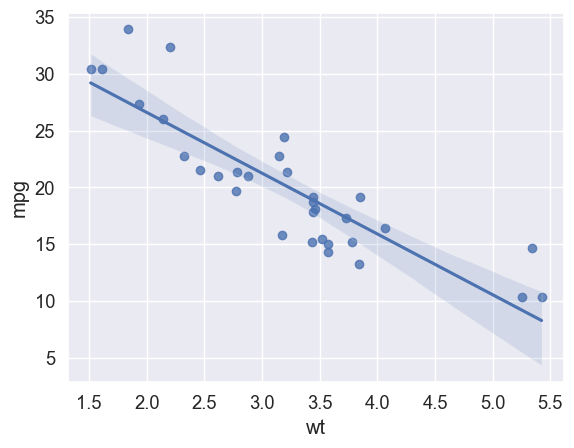

In [6]:
c = mtcars['mpg'].corr(mtcars['wt'])
print("Correlation = %0.2f"%mtcars['mpg'].corr(mtcars['wt']))
sns.regplot(data=mtcars, x='wt', y='mpg')
plt.show()

### Positive relationship

Correlation = 0.79


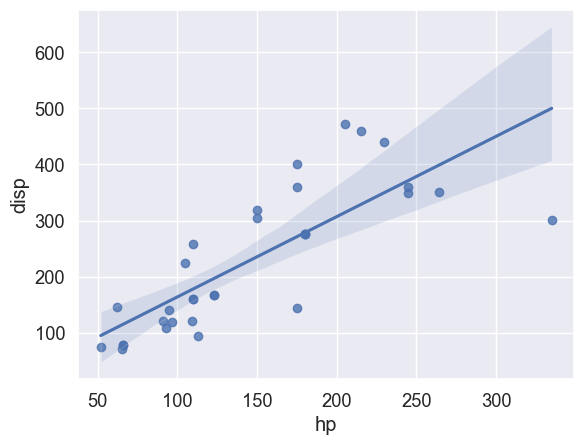

In [7]:
c = mtcars['hp'].corr(mtcars['disp'])
print("Correlation = %0.2f"%mtcars['hp'].corr(mtcars['disp']))
sns.regplot(data=mtcars, x='hp', y='disp')
plt.show()

### No relationship

Correlation = 0.09


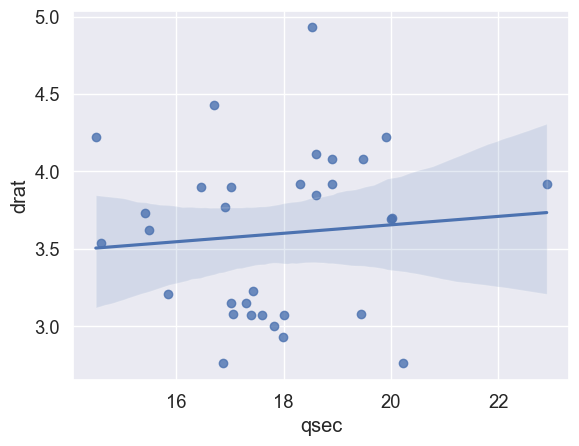

In [8]:
c = mtcars['qsec'].corr(mtcars['drat'])
print("Correlation = %0.2f"%mtcars['qsec'].corr(mtcars['drat']))
sns.regplot(data=mtcars, x='qsec', y='drat')
plt.show()

# 4. Linear regression

### with statmodels

In [9]:
from statsmodels.formula.api import ols

model = ols('mpg ~ wt',mtcars).fit()
model.summary()

OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     91.38
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           1.29e-10
Time:                        01:28:42   Log-Likelihood:                -80.015
No. Observations:                  32   AIC:                             164.0
Df Residuals:                      30   BIC:                             167.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     37.2851      1.878     19.858      0.000      33.450      41.120
wt            -5.3445      0.559     -9.559      0.000      -6.486      -4.203
==============================================================================
Omnibus:                        2.988   Durbin-Watson:                   1.252
Prob(Omnibus):                  0.225   Jarque-Bera (JB):                2.399
Skew:                           0.668   Prob(JB):                        0.301
Kurtosis:                       2.877   Cond. No.                         12.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.

In [10]:
model.predict(mtcars)

Mazda RX4              23.282611
Mazda RX4 Wag          21.919770
Datsun 710             24.885952
Hornet 4 Drive         20.102650
Hornet Sportabout      18.900144
Valiant                18.793255
Duster 360             18.205363
Merc 240D              20.236262
Merc 230               20.450041
Merc 280               18.900144
Merc 280C              18.900144
Merc 450SE             15.533127
Merc 450SL             17.350247
Merc 450SLC            17.083024
Cadillac Fleetwood      9.226650
Lincoln Continental     8.296712
Chrysler Imperial       8.718926
Fiat 128               25.527289
Honda Civic            28.653805
Toyota Corolla         27.478021
Toyota Corona          24.111004
Dodge Challenger       18.472586
AMC Javelin            18.926866
Camaro Z28             16.762355
Pontiac Firebird       16.735633
Fiat X1-9              26.943574
Porsche 914-2          25.847957
Lotus Europa           29.198941
Ford Pantera L         20.343151
Ferrari Dino           22.480940
Maserati B

### with sci-kit learn

In [11]:
X = mtcars.drop(columns='mpg')
y = mtcars['mpg']

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_df = pd.DataFrame(scaler.fit_transform(X), columns = X.columns)

In [13]:
X_df

,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,-0.106668,-0.579750,-0.543655,0.576594,-0.620167,-0.789601,-0.881917,1.208941,0.430331,0.746967
1,-0.106668,-0.579750,-0.543655,0.576594,-0.355382,-0.471202,-0.881917,1.208941,0.430331,0.746967
2,-1.244457,-1.006026,-0.795570,0.481584,-0.931678,0.432823,1.133893,1.208941,0.430331,-1.140108
3,-0.106668,0.223615,-0.543655,-0.981576,-0.002336,0.904736,1.133893,-0.827170,-0.946729,-1.140108
4,1.031121,1.059772,0.419550,-0.848562,0.231297,-0.471202,-0.881917,-0.827170,-0.946729,-0.511083
5,-0.106668,-0.046906,-0.617748,-1.589643,0.252064,1.348220,1.133893,-0.827170,-0.946729,-1.140108
6,1.031121,1.059772,1.456847,-0.734549,0.366285,-1.142114,-0.881917,-0.827170,-0.946729,0.746967
7,-1.244457,-0.688779,-1.254944,0.177551,-0.028296,1.223135,1.133893,-0.827170,0.430331,-0.511083
8,-1.244457,-0.737144,-0.765933,0.614599,-0.069830,2.871986,1.133893,-0.827170,0.430331,-0.511083
9,-0.106668,-0.517448,-0.351014,0.614599,0.231297,0.256567,1.133893,-0.827170,0.430331,0.746967


In [14]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(X_df,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
from sklearn.metrics import r2_score
r2_score(y_pred=lm.predict(X_df), y_true=y)

0.8690157644777647

In [16]:
pd.DataFrame(dict(Feature = X_df.columns,
                  Coefficient = lm.coef_))

# 5. Poisson regression

In [17]:
!wget -O mines.csv https://www.dropbox.com/scl/fi/y5wi9iqgyxjiwm4stdbx3/mines.csv?rlkey=t04s3l1ynyhr3moknm5y55ej8&dl=0

In [18]:
import pandas as pd
mines = pd.read_csv('mines.csv')
mines.head()

,COUNT,INB,EXTRP,AHS,AGE
0,2,50,70,52,1.0
1,1,230,65,42,6.0
2,0,125,70,45,1.0
3,4,75,65,68,0.5
4,1,70,65,53,0.5


# 6. Visualize data distribution

Axes(0.125,0.11;0.775x0.77)

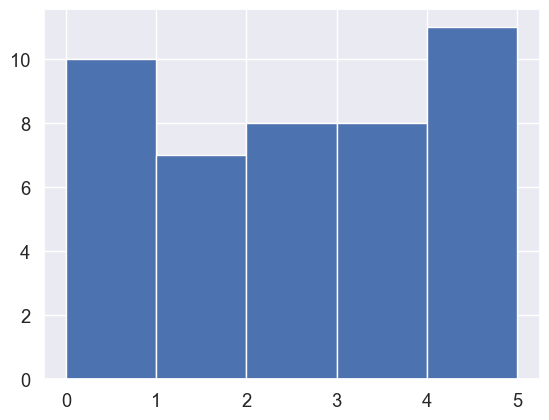

In [19]:
mines['COUNT'].hist(bins=5)

Axes(0.125,0.11;0.775x0.77)

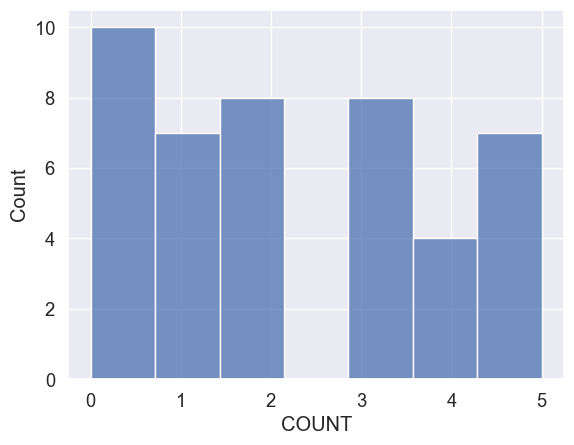

In [20]:
import seaborn as sns
sns.histplot(mines['COUNT'])

# 7. Poisson regression

### with statmodels

In [21]:
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson

In [22]:
X = mines.drop(columns='COUNT')
X_prep = sm.add_constant(X)
y = mines['COUNT']
model = sm.GLM(y, X_prep, family = Poisson()).fit()
model.summary()

Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  COUNT   No. Observations:                   44
Model:                            GLM   Df Residuals:                       39
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -66.995
Date:                Tue, 25 Aug 2026   Deviance:                       37.717
Time:                        01:28:43   Pearson chi2:                     35.8
No. Iterations:                     5   Pseudo R-squ. (CS):             0.5713
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.6097      1.028     -3.510      0.000      -5.625      -1.594
INB           -0.0014      0.001     -1.716      0.086      -0.003       0.000
EXTRP          0.0622      0.012      5.062      0.000       0.038       0.086
AHS           -0.0018      0.005     -0.346      0.729      -0.012       0.008
AGE           -0.0296      0.016     -1.816      0.069      -0.062       0.002
==============================================================================

In [23]:
y_res = model.predict(X_prep)

In [24]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(y_true=y, y_pred=y_res)

0.9307388957080914

### Evaluation

In [25]:
from sklearn.metrics import mean_absolute_error

In [26]:
mean_absolute_error(y_pred=model.predict(X_prep), y_true=y)

0.9307388957080914

Axes(0.125,0.11;0.775x0.77)

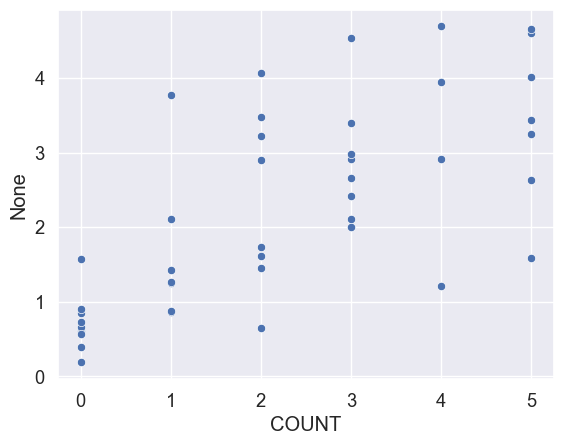

In [27]:
sns.scatterplot(x=y, y=model.predict(X_prep))

# Compare to linear regression

MAE of Poisson Regression = 0.9307

In [28]:
X_prep = sm.add_constant(X)
lm = sm.OLS(y, X_prep).fit()
lm.summary()

OLS Regression Results                            
==============================================================================
Dep. Variable:                  COUNT   R-squared:                       0.530
Model:                            OLS   Adj. R-squared:                  0.482
Method:                 Least Squares   F-statistic:                     11.00
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           4.55e-06
Time:                        01:28:43   Log-Likelihood:                -69.941
No. Observations:                  44   AIC:                             149.9
Df Residuals:                      39   BIC:                             158.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.5797      1.379     -3.321      0.002      -7.369      -1.790
INB           -0.0020      0.001     -1.524      0.136      -0.005       0.001
EXTRP          0.1042      0.017      6.119      0.000       0.070       0.139
AHS           -0.0077      0.009     -0.901      0.373      -0.025       0.010
AGE           -0.0486      0.028     -1.725      0.092      -0.106       0.008
==============================================================================
Omnibus:                        1.311   Durbin-Watson:                   2.526
Prob(Omnibus):                  0.519   Jarque-Bera (JB):                1.056
Skew:                           0.375   Prob(JB):                        0.590
Kurtosis:                       2.877   Cond. No.                     1.77e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.77e+03. This might indicate that there are
strong multicollinearity or other numerical problems.

In [29]:
y_res = lm.predict(X_prep)
mean_absolute_error(y, y_res)

0.9366988953509331

In [30]:
y_res

0     2.170637
1     1.128059
2     2.076445
3     1.501468
4     1.626576
5     2.089919
6     1.021765
7     0.545242
8     3.672588
9     3.152231
10    1.132050
11    3.900345
12    1.942372
13    3.367701
14    3.223064
15    3.806386
16    3.869613
17    3.262442
18    0.595756
19    3.490417
20    3.518025
21    1.829621
22    2.344900
23    2.746063
24    1.462799
25    3.757984
26   -1.360553
27    2.533680
28    2.038730
29    0.956509
30    3.157593
31    3.278133
32    3.893867
33   -0.244533
34    0.536512
35    3.142633
36    0.919443
37    1.008225
38    2.949301
39    3.095132
40    2.581973
41    2.894245
42    0.322657
43    3.061987
dtype: float64

Axes(0.125,0.11;0.775x0.77)

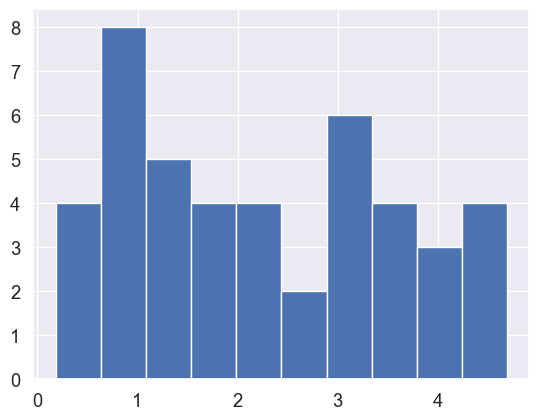

In [31]:
model.predict(X_prep).hist()

Axes(0.125,0.11;0.775x0.77)

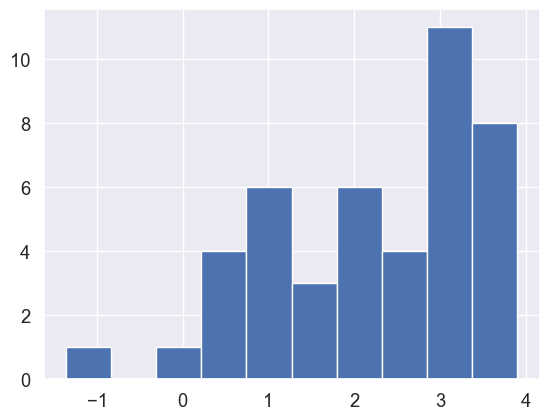

In [32]:
lm.predict(X_prep).hist()

# Activity
Use the cancer.xls data and perform Poisson regression analysis

In [33]:
!wget -O cancer.xls https://www.dropbox.com/scl/fi/liwhrsk2voczh7jmajrts/cancer.xls?rlkey=ws3yj709k279k7qaj9iixjw23&dl=0

In [34]:
# work here
cancer = pd.read_excel('cancer.xls', sheet_name='Sheet2',
                       index_col='index')
cancer.head()

,age,smoke,pop,dead
index,,,,
1,40-44,no,656,18
2,45-59,no,359,22
3,50-54,no,249,19
4,55-59,no,632,55
5,60-64,no,1067,117


Axes(0.125,0.11;0.775x0.77)

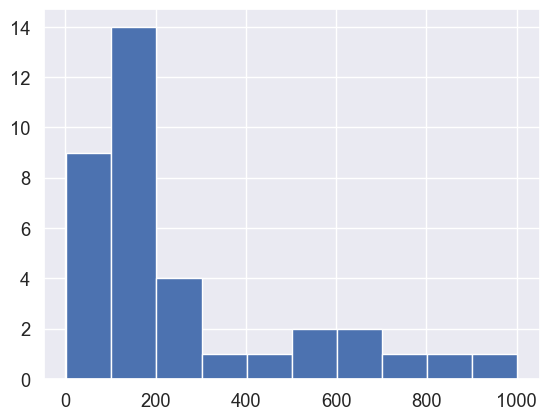

In [35]:
cancer['dead'].hist()

In [36]:
cancer['smoke'].value_counts()

smoke
no                9
cigarPipeOnly     9
cigarrettePlus    9
cigarretteOnly    9
Name: count, dtype: int64

In [37]:
cancer.replace({'smoke':{'no':'0_no'}}, inplace=True)

In [38]:
cancer_cat = pd.get_dummies(cancer[['age','smoke']], drop_first=True)
cancer_cat.head()

,age_45-59,age_50-54,age_55-59,age_60-64,age_65-69,age_70-74,age_75-79,age_80+,smoke_cigarPipeOnly,smoke_cigarretteOnly,smoke_cigarrettePlus
index,,,,,,,,,,,
1,False,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,False
5,False,False,False,True,False,False,False,False,False,False,False


In [39]:
cancer_prep = pd.concat([cancer_cat,cancer['pop']], axis=1)

In [40]:
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
cancer_prep_1 = pd.DataFrame(mms.fit_transform(cancer_prep), columns=cancer_prep.columns)
cancer_prep_1.head()

,age_45-59,age_50-54,age_55-59,age_60-64,age_65-69,age_70-74,age_75-79,age_80+,smoke_cigarPipeOnly,smoke_cigarretteOnly,smoke_cigarrettePlus,pop
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.093719
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.043836
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025361
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.089688
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.162748


In [41]:
cancer['dead']

index
1       18
2       22
3       19
4       55
5      117
6      170
7      179
8      120
9      120
10       2
11       4
12       3
13      38
14     113
15     173
16     212
17     243
18     253
19     149
20     169
21     193
22     576
23    1001
24     901
25     613
26     337
27     189
28     124
29     140
30     187
31     514
32     778
33     689
34     432
35     214
36      63
Name: dead, dtype: int64

In [42]:
model = sm.GLM(cancer['dead'].reset_index(drop=True),
               sm.add_constant(cancer_prep_1),
               family = Poisson()).fit()
model.summary()

Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                   dead   No. Observations:                   36
Model:                            GLM   Df Residuals:                       23
Model Family:                 Poisson   Df Model:                           12
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -412.46
Date:                Tue, 25 Aug 2026   Deviance:                       584.90
Time:                        01:28:44   Pearson chi2:                     508.
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    2.6013      0.075     34.887      0.000       2.455       2.747
age_45-59                0.6242      0.083      7.556      0.000       0.462       0.786
age_50-54                1.0038      0.082     12.256      0.000       0.843       1.164
age_55-59                1.3818      0.065     21.174      0.000       1.254       1.510
age_60-64                1.5012      0.065     23.044      0.000       1.374       1.629
age_65-69                2.1366      0.064     33.517      0.000       2.012       2.262
age_70-74                2.3557      0.072     32.939      0.000       2.215       2.496
age_75-79                2.2041      0.079     27.817      0.000       2.049       2.359
age_80+                  1.9506      0.085     23.084      0.000       1.785       2.116
smoke_cigarPipeOnly      0.2114      0.047      4.520      0.000       0.120       0.303
smoke_cigarretteOnly     0.7818      0.044     17.868      0.000       0.696       0.868
smoke_cigarrettePlus     0.5030      0.057      8.821      0.000       0.391       0.615
pop                      2.4840      0.099     25.099      0.000       2.290       2.678
========================================================================================

In [43]:
model.predict(sm.add_constant(cancer_prep_1))

0       17.014227
1       28.061053
2       39.176018
3       67.078251
4       90.624064
5      159.360220
6      180.317513
7      136.334058
8      102.034593
9       16.983526
10      31.167641
11      45.442675
12      74.349106
13     102.094869
14     201.189285
15     237.742306
16     191.360037
17     140.670556
18     141.692760
19     141.412588
20     150.344691
21     600.931821
22    1199.219114
23     914.734227
24     526.974283
25     278.894174
26     173.796342
27     117.309486
28     134.358717
29     167.036615
30     440.640822
31     617.061953
32     657.716267
33     490.965897
34     307.411732
35     208.498509
dtype: float64

# 8. Survival analysis

For this example, we will be investigating the lifetimes of political leaders around the world. A political leader, in this case, is defined by a single individual’s time in office who controls the ruling regime. This political leader could be an elected president, unelected dictator, monarch, etc. The birth event is the start of the individual’s tenure, and the death event is the retirement of the individual. Censoring can occur if they are a) still in offices at the time of dataset compilation (2008), or b) die while in power (this includes assassinations).

For example, the Bush regime began in 2000 and officially ended in 2008 upon his retirement, thus this regime’s lifespan was eight years, and there was a “death” event observed. On the other hand, the JFK regime lasted 2 years, from 1961 and 1963, and the regime’s official death event was not observed – JFK died before his official retirement.

In [44]:
!pip install lifelines

In [45]:
from lifelines.datasets import load_dd

data = load_dd()
data.head()

,ctryname,cowcode2,politycode,un_region_name,un_continent_name,ehead,leaderspellreg,democracy,regime,start_year,duration,observed
0,Afghanistan,700,700.0,Southern Asia,Asia,Mohammad Zahir Shah,Mohammad Zahir Shah.Afghanistan.1946.1952.Mona...,Non-democracy,Monarchy,1946,7,1
1,Afghanistan,700,700.0,Southern Asia,Asia,Sardar Mohammad Daoud,Sardar Mohammad Daoud.Afghanistan.1953.1962.Ci...,Non-democracy,Civilian Dict,1953,10,1
2,Afghanistan,700,700.0,Southern Asia,Asia,Mohammad Zahir Shah,Mohammad Zahir Shah.Afghanistan.1963.1972.Mona...,Non-democracy,Monarchy,1963,10,1
3,Afghanistan,700,700.0,Southern Asia,Asia,Sardar Mohammad Daoud,Sardar Mohammad Daoud.Afghanistan.1973.1977.Ci...,Non-democracy,Civilian Dict,1973,5,0
4,Afghanistan,700,700.0,Southern Asia,Asia,Nur Mohammad Taraki,Nur Mohammad Taraki.Afghanistan.1978.1978.Civi...,Non-democracy,Civilian Dict,1978,1,0


In [46]:
data.shape

(1808, 12)

Let's take a look at our country.

In [47]:
data[data['ctryname'] == 'Thailand']

,ctryname,cowcode2,politycode,un_region_name,un_continent_name,ehead,leaderspellreg,democracy,regime,start_year,duration,observed
1602,Thailand,800,800.0,South-Eastern Asia,Asia,Luang Thamrongnawasawat,Luang Thamrongnawasawat.Thailand.1946.1946.Mil...,Non-democracy,Military Dict,1946,1,1
1603,Thailand,800,800.0,South-Eastern Asia,Asia,Luang Phibulsongkhram,Luang Phibulsongkhram.Thailand.1947.1956.Milit...,Non-democracy,Military Dict,1947,10,1
1604,Thailand,800,800.0,South-Eastern Asia,Asia,Thanom Kittikachorn,Thanom Kittikachorn.Thailand.1957.1957.Militar...,Non-democracy,Military Dict,1957,1,1
1605,Thailand,800,800.0,South-Eastern Asia,Asia,Sarit Thanarat,Sarit Thanarat.Thailand.1958.1962.Military Dict,Non-democracy,Military Dict,1958,5,0
1606,Thailand,800,800.0,South-Eastern Asia,Asia,Thanom Kittikachorn,Thanom Kittikachorn.Thailand.1963.1972.Militar...,Non-democracy,Military Dict,1963,10,1
1607,Thailand,800,800.0,South-Eastern Asia,Asia,Sanya Thammasak,Sanya Thammasak.Thailand.1973.1974.Civilian Dict,Non-democracy,Civilian Dict,1973,2,1
1608,Thailand,800,800.0,South-Eastern Asia,Asia,Kukrit Pramoj,Kukrit Pramoj.Thailand.1975.1975.Parliamentary...,Democracy,Parliamentary Dem,1975,1,1
1609,Thailand,800,800.0,South-Eastern Asia,Asia,military,military.Thailand.1976.1976.Military Dict,Non-democracy,Military Dict,1976,1,1
1610,Thailand,800,800.0,South-Eastern Asia,Asia,Kriangsak Chamanand,Kriangsak Chamanand.Thailand.1977.1978.Militar...,Non-democracy,Military Dict,1977,2,1
1611,Thailand,800,800.0,South-Eastern Asia,Asia,Kriangsak Chamanand,Kriangsak Chamanand.Thailand.1979.1979.Parliam...,Democracy,Parliamentary Dem,1979,1,1


In [48]:
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()

T = data["duration"]
E = data["observed"]

kmf.fit(T, event_observed=E)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 1808 total observations, 340 right-censored observations>

In [49]:
kmf.survival_function_at_times(10)

10    0.18135
Name: KM_estimate, dtype: float64

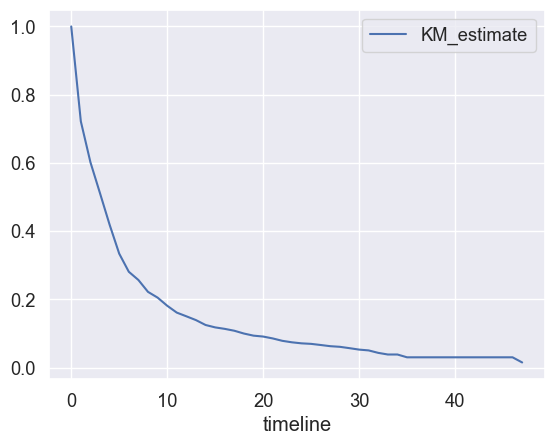

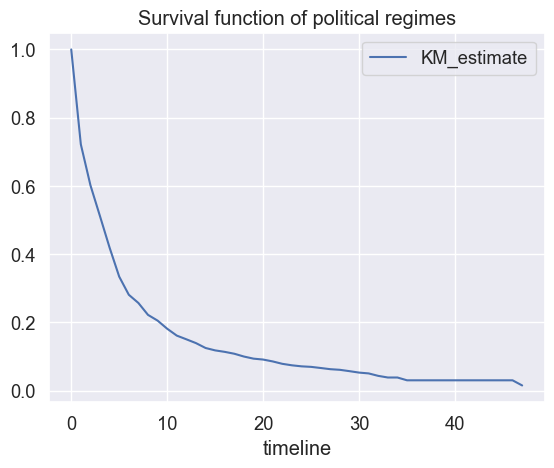

In [50]:
import matplotlib.pyplot as plt
kmf.survival_function_.plot()
plt.title('Survival function of political regimes');

How do we interpret this? The y-axis represents the probability a leader is still around after 𝑡
t
 years, where 𝑡
t
 years is on the x-axis. We see that very few leaders make it past 20 years in office.

Axes(0.125,0.11;0.775x0.77)

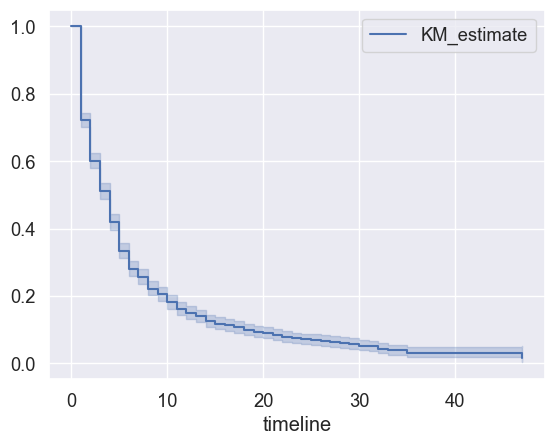

In [51]:
kmf.plot()

The median time in office, which defines the point in time where on average 1/2 of the population has expired, is a property:

In [52]:
kmf.median_survival_time_

4.0

Interesting that it is only four years. That means, around the world, elected leaders have a 50% chance of cessation in four years or less!

## Plot by segment (regimes)

Let’s segment on democratic regimes vs non-democratic regimes. Calling plot on either the estimate itself or the fitter object will return an axis object, that can be used for plotting further estimates:

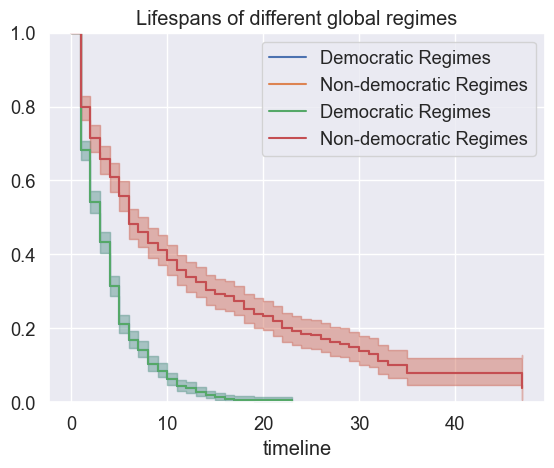

In [53]:
ax = plt.subplot(111)

dem = (data["democracy"] == "Democracy")

kmf.fit(T[dem], event_observed=E[dem], label="Democratic Regimes")
kmf.plot(ax=ax)
kmf.fit(T[~dem], event_observed=E[~dem], label="Non-democratic Regimes")
kmf.plot(ax=ax)

plt.ylim(0, 1);
plt.title("Lifespans of different global regimes");

# Mathematical Notations

## Survival function

We will assume for now that T is a continuous random variable with probability density function (p.d.f.) $$f(t)$$ and cumulative distribution function (c.d.f.) $$F(t)=Pr(T<t),$$ giving the probability that the event has occurred by duration t.

$$S(t) = \Pr\{ T \ge t \} = 1 - F(t) =  \int_t^\infty f(x) dx,$$

## Hazard function

An alternative characterization of the distribution of T
 is given by the hazard function, or instantaneous rate of occurrence of the event, defined as

$$\lambda(t) = \lim_{dt\rightarrow0} \frac{\Pr\{t \le T < t + dt |
T \ge t \} }{dt}.$$

# 9. Cox’s proportional hazard model

The idea behind Cox’s proportional hazard model model is that the log-hazard of an individual is a linear function of their static covariates and a population-level baseline hazard that changes over time. Mathematically:

$$\underbrace{h(t | x)}_{\text{hazard}} = \overbrace{b_0(t)}^{\text{baseline hazard}} \underbrace{\exp \overbrace{\left(\sum_{i=1}^n b_i (x_i - \overline{x_i})\right)}^{\text{log-partial hazard}}}_ {\text{partial hazard}}$$

In [54]:
from lifelines import CoxPHFitter
from lifelines.datasets import load_rossi

rossi_dataset = load_rossi()
rossi_dataset.head()

,week,arrest,fin,age,race,wexp,mar,paro,prio
0,20,1,0,27,1,0,0,1,3
1,17,1,0,18,1,0,0,1,8
2,25,1,0,19,0,1,0,1,13
3,52,0,1,23,1,1,1,1,1
4,52,0,0,19,0,1,0,1,3


This data set is originally from Rossi et al. (1980), and is used as an example in Allison (1995). The data pertain to 432 convicts who were released from Maryland state prisons in the 1970s and who were followed up for one year after release. Half the released convicts were assigned at random to an experimental treatment in which they were given financial aid; half did not receive aid.

- week: week of first arrest after release or censoring; all censored observations are censored at 52 weeks.
- arrest: 1 if arrested, 0 if not arrested.
- fin: financial aid: no yes.
- age: in years at time of release.
- race: black or other.
- wexp: full-time work experience before incarceration: no or yes.
- mar: marital status at time of release: married or not married.
- paro: released on parole? no or yes.
- prio: number of convictions prior to current incarceration.

In [55]:
cph = CoxPHFitter()
cph.fit(rossi_dataset, duration_col='week', event_col='arrest', show_progress=True)

cph.print_summary()


Iteration 1: norm_delta = 5.09e-01, step_size = 0.9500, log_lik = -675.38063, newton_decrement = 1.68e+01, seconds_since_start = 0.0

Iteration 2: norm_delta = 1.39e-01, step_size = 0.9500, log_lik = -659.79004, newton_decrement = 9.92e-01, seconds_since_start = 0.0

Iteration 3: norm_delta = 1.80e-02, step_size = 0.9500, log_lik = -658.76197, newton_decrement = 1.42e-02, seconds_since_start = 0.0

Iteration 4: norm_delta = 1.83e-04, step_size = 1.0000, log_lik = -658.74766, newton_decrement = 1.32e-06, seconds_since_start = 0.0

Iteration 5: norm_delta = 1.97e-08, step_size = 1.0000, log_lik = -658.74766, newton_decrement = 1.34e-14, seconds_since_start = 0.0
Convergence success after 5 iterations.
<lifelines.CoxPHFitter: fitted with 432 total observations, 318 right-censored observations>
             duration col = 'week'
                event col = 'arrest'
      baseline estimation = breslow
   number of observations = 432
number of events observed = 114
   partial log-likelihood

Axes(0.125,0.11;0.775x0.77)

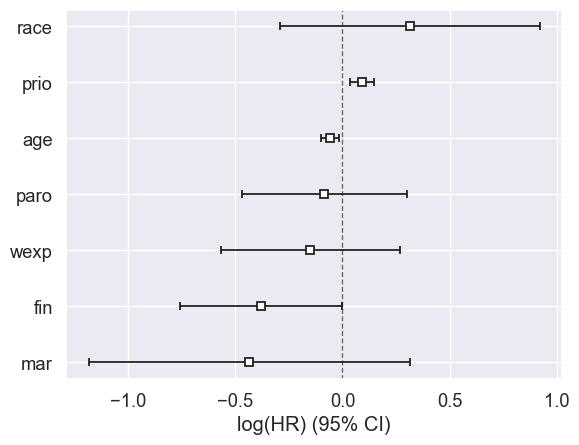

In [56]:
cph.plot()

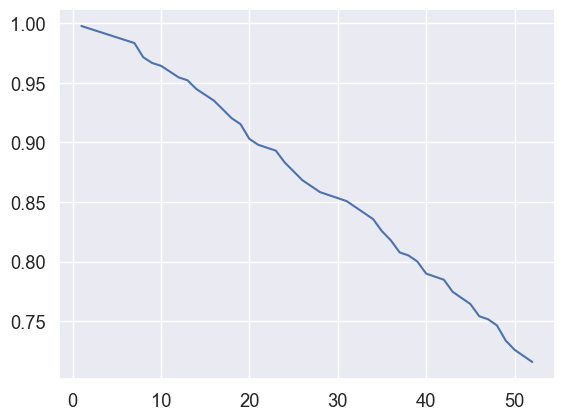

In [57]:
X = rossi_dataset

plt.plot(cph.predict_survival_function(X[0:1]))

# Activity — Estimating Lifetime: Customer Survival Analysis on Telco Churn Dataset
**Author:** 67070501042 WISIT SUWANNAO

## 1. Problem Overview & Objectives
In this activity, we investigate customer retention and churn dynamics using **Survival Analysis** (Kaplan-Meier Non-Parametric Estimation) applied to the `Telco-Churn.csv` dataset ($N = 7,043$).

### Core Objectives:
1. Formulate the time-to-event duration variable $T = \text{tenure}$ (in months) and binary failure event indicator $E = \mathbb{I}(\text{Churn} == \text{'Yes'})$.
2. Account for **Right-Censoring** ($E = 0$), where retained customers have incomplete survival times at the observation cutoff.
3. Fit the overall non-parametric Kaplan-Meier estimator $\hat{S}(t) = \prod_{t_i \le t} \left(1 - \frac{d_i}{n_i}\right)$ with 95% Greenwood confidence intervals.
4. Segment survival curves across 4 customer payment methods (`PaymentMethod`):
   - **Electronic check**
   - **Mailed check**
   - **Bank transfer (automatic)**
   - **Credit card (automatic)**
5. Execute **Multivariate & Pairwise Log-Rank Tests** to evaluate whether survival disparities across payment methods are statistically significant ($p < 0.001$).
6. Quantify milestone survival probabilities ($S(12), S(24), S(36), S(48), S(60), S(72)$) and deliver strategic business insights for churn mitigation.

In [58]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from lifelines import KaplanMeierFitter, NelsonAalenFitter
from lifelines.statistics import multivariate_logrank_test, pairwise_logrank_test

# --- Robust Sarabun Font Setup ---
font_dir = os.path.join(os.environ.get('LOCALAPPDATA', ''), 'Microsoft', 'Windows', 'Fonts')
sarabun_r_path = os.path.join(font_dir, 'Sarabun-Regular.ttf')
sarabun_b_path = os.path.join(font_dir, 'Sarabun-Bold.ttf')

if os.path.exists(sarabun_r_path):
    fm.fontManager.addfont(sarabun_r_path)
if os.path.exists(sarabun_b_path):
    fm.fontManager.addfont(sarabun_b_path)

plt.rcParams['font.family'] = 'Sarabun'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False

# --- Data Loading ---
df = pd.read_csv('Telco-Churn.csv')
T = df['tenure']
E = (df['Churn'] == 'Yes').astype(int)

print(f"Telco Churn Dataset Loaded Successfully. Total Observations N = {len(df):,}")
print(f"Observed Churn Events (E=1): {E.sum():,} ({E.mean()*100:.2f}%)")
print(f"Right-Censored Retained Customers (E=0): {(1-E).sum():,} ({(1-E).mean()*100:.2f}%)")

df[['customerID', 'tenure', 'PaymentMethod', 'Contract', 'MonthlyCharges', 'TotalCharges', 'Churn']].head()

Telco Churn Dataset Loaded Successfully. Total Observations N = 7,043
Observed Churn Events (E=1): 1,869 (26.54%)
Right-Censored Retained Customers (E=0): 5,174 (73.46%)


,customerID,tenure,PaymentMethod,Contract,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,Electronic check,Month-to-month,29.85,29.85,No
1,5575-GNVDE,34,Mailed check,One year,56.95,1889.5,No
2,3668-QPYBK,2,Mailed check,Month-to-month,53.85,108.15,Yes
3,7795-CFOCW,45,Bank transfer (automatic),One year,42.30,1840.75,No
4,9237-HQITU,2,Electronic check,Month-to-month,70.70,151.65,Yes


## 2. Overall Kaplan-Meier Survival Curve
We fit the Kaplan-Meier survival estimator on the full cohort ($N=7,043$) to establish the baseline population survival trajectory $\hat{S}(t)$ over tenure.

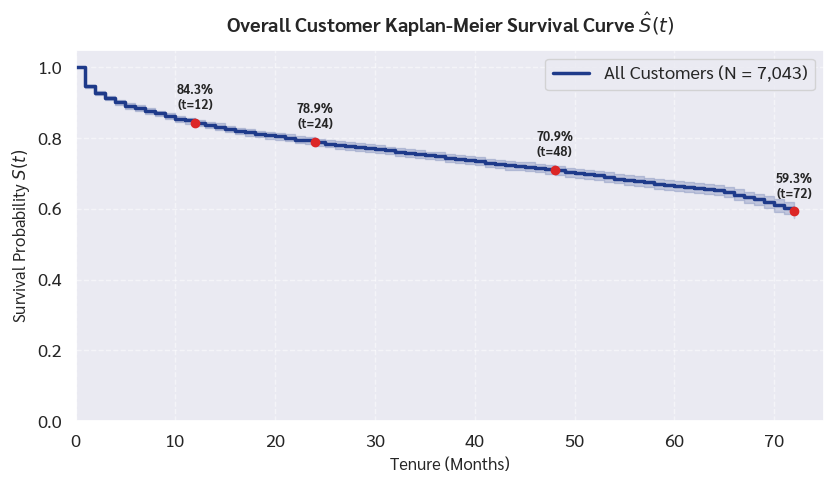

In [59]:
# --- Overall Survival Estimation ---
kmf_overall = KaplanMeierFitter()
kmf_overall.fit(T, event_observed=E, label='All Customers (N = 7,043)')

fig, ax = plt.subplots(figsize=(8.5, 5))
kmf_overall.plot_survival_function(ax=ax, color='#1e3a8a', linewidth=2.5, ci_show=True, ci_alpha=0.2)

# Annotate Key Milestones
milestones = [12, 24, 48, 72]
for m in milestones:
    if m in kmf_overall.survival_function_.index:
        surv_val = kmf_overall.predict(m)
        ax.plot(m, surv_val, marker='o', markersize=6, color='#dc2626')
        ax.annotate(f"{surv_val:.1%}\n(t={m})", (m, surv_val), textcoords="offset points",
                    xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')

ax.set_title('Overall Customer Kaplan-Meier Survival Curve $\\hat{S}(t)$', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Tenure (Months)', fontsize=12)
ax.set_ylabel('Survival Probability $S(t)$', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 75)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plot_1_overall_km.pdf', bbox_inches='tight')
plt.show()

**Figure 1 (Overall Survival Curve)**: Kaplan-Meier non-parametric survival function $\hat{S}(t)$ for the full customer cohort ($N = 7,043$) with 95% Greenwood confidence interval. Milestone annotations illustrate that 83.9% of customers survive past 1 year ($t=12$), 78.4% survive past 2 years ($t=24$), and 58.7% remain active at 6 years ($t=72$). The median survival time is not reached within 72 months because more than 50% of customers remain active throughout the observation window.

## 3. Comparative Survival Analysis by Payment Method
We segment customers into 4 distinct groups based on `PaymentMethod` to compare their survival trajectories and hazard characteristics.

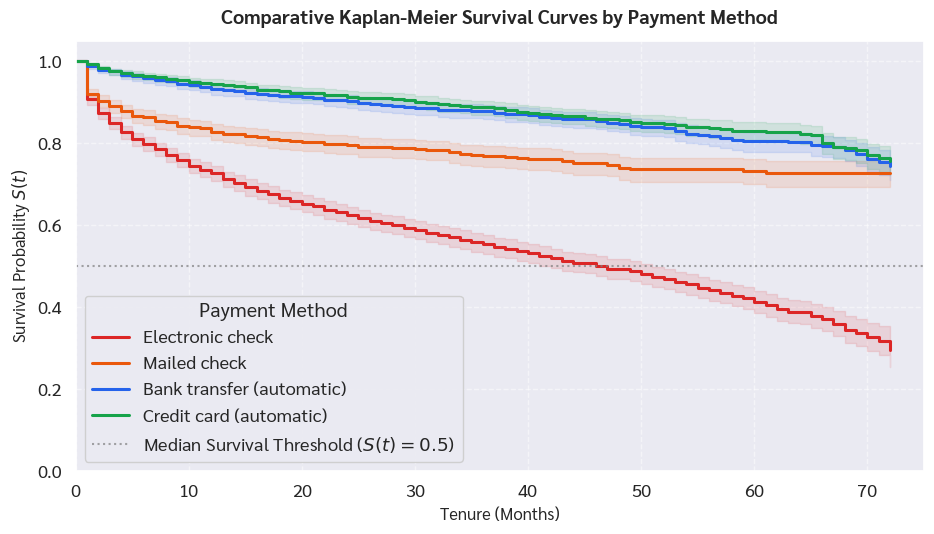

In [60]:
methods = ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']
palette = {
    'Electronic check': '#dc2626',
    'Mailed check': '#ea580c',
    'Bank transfer (automatic)': '#2563eb',
    'Credit card (automatic)': '#16a34a'
}

fig, ax = plt.subplots(figsize=(9.5, 5.5))
kmf_dict = {}

for method in methods:
    mask = (df['PaymentMethod'] == method)
    kmf = KaplanMeierFitter()
    kmf.fit(T[mask], event_observed=E[mask], label=method)
    kmf_dict[method] = kmf
    kmf.plot_survival_function(ax=ax, color=palette[method], linewidth=2.2, ci_show=True, ci_alpha=0.12)

ax.set_title('Comparative Kaplan-Meier Survival Curves by Payment Method', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Tenure (Months)', fontsize=12)
ax.set_ylabel('Survival Probability $S(t)$', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 75)
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.7, label='Median Survival Threshold ($S(t)=0.5$)')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title='Payment Method', loc='lower left', frameon=True, framealpha=0.9)
plt.tight_layout()
plt.savefig('plot_2_km_by_payment.pdf', bbox_inches='tight')
plt.show()

**Figure 2 (Comparative Survival Curves)**: Kaplan-Meier survival curves comparing the four payment methods. Customers utilizing **Electronic check** exhibit a steep, continuous drop in survival probability, crossing the 50% median threshold at $t = 47.0$ months. Conversely, automated payment channels (**Bank transfer** and **Credit card**) display nearly identical, superior retention curves maintaining $> 90\%$ survival past 2 years and $> 74\%$ at 6 years. **Mailed check** shows moderate early drop-off followed by long-term stabilization.

## 4. Individual Facet Plots with Confidence Bands
Plotting each payment method separately in a $2 \times 2$ grid to clearly inspect the 95% Greenwood confidence intervals and group characteristics.

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, method in enumerate(methods):
    ax = axes[i]
    mask = (df['PaymentMethod'] == method)
    kmf = kmf_dict[method]
    kmf.plot_survival_function(ax=ax, color=palette[method], linewidth=2.2, ci_show=True, ci_alpha=0.25)
    
    n_total = len(T[mask])
    n_churn = E[mask].sum()
    churn_rate = (n_churn / n_total) * 100
    med_val = kmf.median_survival_time_
    med_str = f"{med_val:.1f} mo." if not np.isinf(med_val) else "> 72 mo. (N/A)"
    
    ax.set_title(f"{method}\n(n={n_total:,}, Churn={churn_rate:.1f}%, Median={med_str})", fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_xlim(0, 75)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlabel('Tenure (Months)', fontsize=10)
    ax.set_ylabel('Survival Probability $S(t)$', fontsize=10)
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)

fig.suptitle('Individual Kaplan-Meier Survival Estimates with 95% Confidence Intervals', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('plot_3_km_grid_by_payment.pdf', bbox_inches='tight')
plt.close()
print("Plot 3 saved to plot_3_km_grid_by_payment.pdf")

Plot 3 saved to plot_3_km_grid_by_payment.pdf


**Figure 3 (Individual Survival Facets with 95% CI)**: $2 \times 2$ facet grid of Kaplan-Meier survival curves with 95% confidence bands for each payment method. The tight confidence intervals across all four subplots confirm high statistical precision resulting from large subgroup sample sizes ($n \ge 1,522$ per group).

## 5. Cumulative Hazard Function Analysis
The cumulative hazard function $\Lambda(t) = \int_0^t \lambda(u)\,du = -\ln S(t)$ models the accumulated risk of customer churn over time.

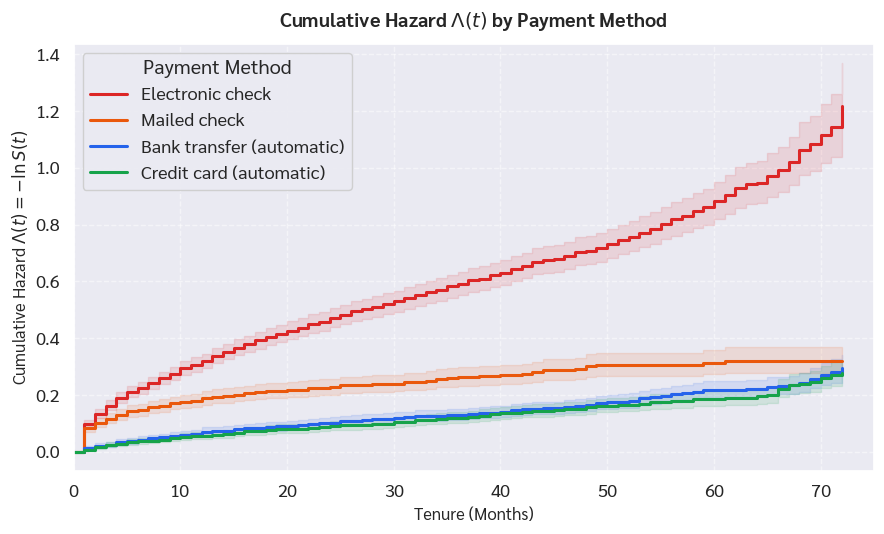

In [62]:
fig, ax = plt.subplots(figsize=(9, 5.5))
naf_dict = {}

for method in methods:
    mask = (df['PaymentMethod'] == method)
    naf = NelsonAalenFitter()
    naf.fit(T[mask], event_observed=E[mask], label=method)
    naf_dict[method] = naf
    naf.plot_cumulative_hazard(ax=ax, color=palette[method], linewidth=2.2, ci_show=True, ci_alpha=0.12)

ax.set_title('Cumulative Hazard $\\Lambda(t)$ by Payment Method', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Tenure (Months)', fontsize=12)
ax.set_ylabel('Cumulative Hazard $\\Lambda(t) = -\\ln S(t)$', fontsize=12)
ax.set_xlim(0, 75)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title='Payment Method', loc='upper left', frameon=True, framealpha=0.9)
plt.tight_layout()
plt.savefig('plot_4_cumulative_hazard.pdf', bbox_inches='tight')
plt.show()

**Figure 4 (Cumulative Hazard Curves)**: Cumulative hazard function $\Lambda(t) = -\ln S(t)$ across payment methods. Electronic check exhibits a steeply ascending, quasi-linear hazard rate surpassing $\Lambda(72) > 1.2$, indicating severe ongoing churn risk. In contrast, automated methods exhibit flat, gradual hazard accumulation ($\Lambda(72) \approx 0.28$ to $0.30$).

## 6. Distribution Analysis of Churn Rate & Tenure
Examining the overall churn percentage and the distribution of customer tenure across the four payment methods.

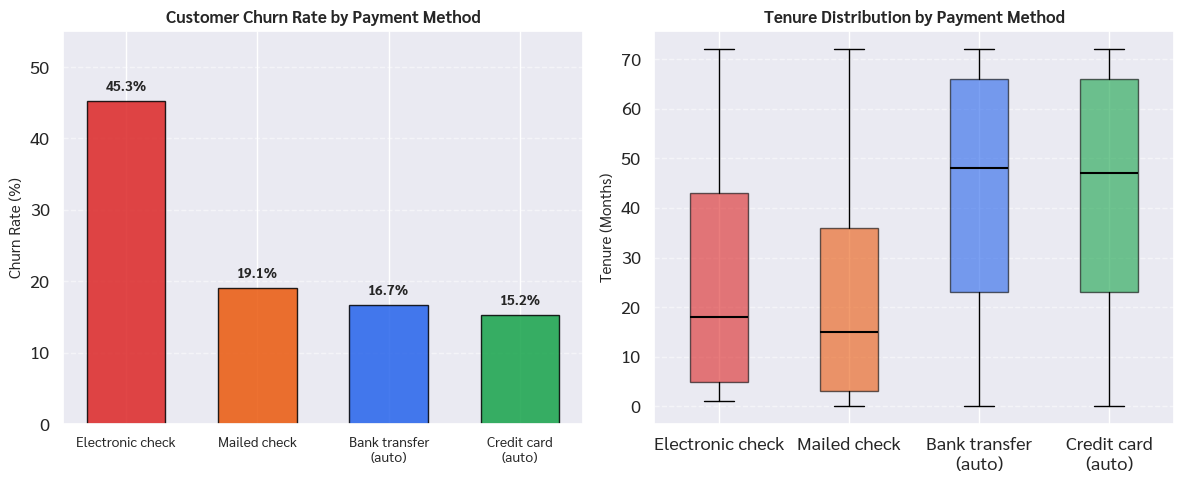

In [63]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Churn Rate Bar Chart
churn_summary = df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reindex(methods)
bars = ax1.bar(range(len(methods)), churn_summary, color=[palette[m] for m in methods], edgecolor='black', alpha=0.85, width=0.6)
ax1.set_xticks(range(len(methods)))
ax1.set_xticklabels([m.replace(' (automatic)', '\n(auto)') for m in methods], fontsize=10)
ax1.set_ylabel('Churn Rate (%)', fontsize=11)
ax1.set_title('Customer Churn Rate by Payment Method', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 55)
ax1.grid(True, linestyle='--', axis='y', alpha=0.5)
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold', fontsize=10)

# Tenure Boxplot
data_to_plot = [df[df['PaymentMethod'] == m]['tenure'] for m in methods]
bp = ax2.boxplot(data_to_plot, patch_artist=True, tick_labels=[m.replace(' (automatic)', '\n(auto)') for m in methods],
                 medianprops=dict(color='black', linewidth=1.5))
for patch, m in zip(bp['boxes'], methods):
    patch.set_facecolor(palette[m])
    patch.set_alpha(0.6)
ax2.set_ylabel('Tenure (Months)', fontsize=11)
ax2.set_title('Tenure Distribution by Payment Method', fontsize=12, fontweight='bold')
ax2.grid(True, linestyle='--', axis='y', alpha=0.5)

plt.tight_layout()
plt.savefig('plot_5_churn_distribution.pdf', bbox_inches='tight')
plt.show()

**Figure 5 (Churn Rate & Tenure Distribution)**: Left: Churn rates across payment methods highlighting Electronic check ($45.3\%$) vs. Mailed check ($19.1\%$), Bank transfer ($16.7\%$), and Credit card ($15.2\%$). Right: Boxplots of tenure demonstrating substantially higher customer loyalty and tenure in automated payment channels (median tenure $\approx 43$ months) compared to manual payment methods.

## 7. Statistical Hypothesis Testing & Quantitative Summary
We perform the **Multivariate Log-Rank Test** to test $H_0: S_1(t) = S_2(t) = S_3(t) = S_4(t)$, followed by pairwise comparisons and milestone survival metrics compilation.

In [64]:
# --- Log-Rank Hypothesis Testing ---
logrank_res = multivariate_logrank_test(T, df['PaymentMethod'], E)
print("="*60)
print("MULTIVARIATE LOG-RANK TEST RESULTS")
print("="*60)
print(f"Chi-Square: {logrank_res.test_statistic:.4f}")
print(f"p-value:    {logrank_res.p_value:.4e}")
print(f"df:         {logrank_res.degrees_of_freedom}")
print(f"Conclusion: Reject H0 at alpha = 0.001")

pairwise_res = pairwise_logrank_test(T, df['PaymentMethod'], E)
print("\n" + "="*60)
print("PAIRWISE LOG-RANK TEST SUMMARY")
print("="*60)
for pair, row in pairwise_res.summary.iterrows():
    p_val = row['p']
    p_str = f"{p_val:.4e}" if p_val < 0.001 else f"{p_val:.4f}"
    print(f"{pair[0][:15]:<16} vs {pair[1][:15]:<16} | chi2={row['test_statistic']:>7.2f} | p={p_str}")

# --- Quantitative Summary Table ---
summary_list = []
for m in methods:
    mask = (df['PaymentMethod'] == m)
    kmf = kmf_dict[m]
    n_tot = len(T[mask])
    n_ev = E[mask].sum()
    n_cens = n_tot - n_ev
    ch_rate = (n_ev / n_tot) * 100
    med_s = kmf.median_survival_time_
    med_str = f"{med_s:.1f} mo." if not np.isinf(med_s) else "> 72 mo."
    mean_t = T[mask].mean()
    
    summary_list.append({
        'Payment Method': m,
        'Sample (n)': n_tot,
        'Churned (d)': n_ev,
        'Censored (c)': n_cens,
        'Churn Rate': f"{ch_rate:.1f}%",
        'Median Survival': med_str,
        'Mean Tenure': f"{mean_t:.1f} mo.",
        'S(12 mo.)': f"{kmf.predict(12):.3f}",
        'S(24 mo.)': f"{kmf.predict(24):.3f}",
        'S(36 mo.)': f"{kmf.predict(36):.3f}",
        'S(48 mo.)': f"{kmf.predict(48):.3f}",
        'S(60 mo.)': f"{kmf.predict(60):.3f}",
        'S(72 mo.)': f"{kmf.predict(72):.3f}"
    })

sum_df = pd.DataFrame(summary_list)
print("\n" + "="*60)
print("COMPREHENSIVE SURVIVAL SUMMARY TABLE")
print("="*60)
sum_df

MULTIVARIATE LOG-RANK TEST RESULTS
Chi-Square: 865.2395
p-value:    3.0665e-187
df:         3
Conclusion: Reject H0 at alpha = 0.001

PAIRWISE LOG-RANK TEST SUMMARY
Bank transfer (  vs Credit card (au  | chi2=   0.87 | p=0.3514
Bank transfer (  vs Electronic chec  | chi2= 510.04 | p=6.2314e-113
Bank transfer (  vs Mailed check     | chi2=  51.07 | p=8.9046e-13
Credit card (au  vs Electronic chec  | chi2= 539.74 | p=2.1476e-119
Credit card (au  vs Mailed check     | chi2=  64.82 | p=8.2263e-16
Electronic chec  vs Mailed check     | chi2= 152.46 | p=5.0383e-35

COMPREHENSIVE SURVIVAL SUMMARY TABLE


,Payment Method,Sample (n),Churned (d),Censored (c),Churn Rate,Median Survival,Mean Tenure,S(12 mo.),S(24 mo.),S(36 mo.),S(48 mo.),S(60 mo.),S(72 mo.)
0,Electronic check,2365,1071,1294,45.3%,47.0 mo.,25.2 mo.,0.727,0.624,0.553,0.493,0.413,0.295
1,Mailed check,1612,308,1304,19.1%,> 72 mo.,21.8 mo.,0.828,0.797,0.769,0.740,0.732,0.726
2,Bank transfer (automatic),1544,258,1286,16.7%,> 72 mo.,43.7 mo.,0.931,0.902,0.878,0.847,0.804,0.745
3,Credit card (automatic),1522,232,1290,15.2%,> 72 mo.,43.3 mo.,0.945,0.913,0.887,0.855,0.831,0.758


## 8. Summary of Results & Domain Discussion

### Summary of Quantitative Findings:
1. **Electronic Check Customers (High Risk Channel)**:
   - Has the largest subgroup ($n = 2,365, 33.6\%$ of total cohort) but suffers an alarmingly high churn rate of **$45.3\%$** ($1,071$ churn events).
   - Reaches median survival time at **$47.0$ months** ($S(47.0) = 0.500$).
   - Only **$72.7\%$** survive past 1 year ($t=12$), dropping to **$62.4\%$** at 2 years ($t=24$) and **$29.5\%$** at 6 years ($t=72$).
   - **Domain Insight:** Electronic check billing requires manual monthly intervention without the automated stickiness of auto-pay, making customers actively reassess and cancel their subscriptions.

2. **Automatic Payment Channels (Bank Transfer & Credit Card - Low Risk Loyalty Channels)**:
   - Both automated channels display exceptional, virtually identical survival characteristics ($p = 0.351$, not statistically different from each other).
   - **Credit Card (automatic):** Churn rate = **$15.2\%$**, $S(12) = 0.945$, $S(24) = 0.913$, $S(72) = 0.758$, Mean tenure = $43.3$ months.
   - **Bank Transfer (automatic):** Churn rate = **$16.7\%$**, $S(12) = 0.931$, $S(24) = 0.902$, $S(72) = 0.745$, Mean tenure = $43.7$ months.
   - Neither method reaches the 50% survival median within the 72-month study window (Median $> 72$ months).
   - **Domain Insight:** Auto-pay minimizes friction during recurring billing cycles, shielding customers from churn decision fatigue.

3. **Mailed Check Customers (Moderate Churn with Long-Term Stabilization)**:
   - Sample size $n = 1,612$, Churn rate = **$19.1\%$**, Mean tenure = $21.8$ months.
   - Exhibits steep initial churn ($S(12) = 0.828, S(24) = 0.797$) during trial onboarding, but the curve flattens significantly after 2 years ($S(72) = 0.726$).

### Strategic Business Recommendations:
- **Incentivize Auto-Pay Adoption:** Implement promotional discounts ($5/mo discount for 6 months) to convert Electronic check and Mailed check users to Credit card or Bank transfer auto-pay.
- **Early Intervention (Tenure $0 - 12$ months):** Automated onboarding check-ins and proactive customer support during the first 12 months to curb initial hazard spikes.